In [1]:
import os
import wfdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
records_chf2db = wfdb.get_record_list("chf2db")

print("Number of records:", len(records_chf2db))
print(records_chf2db)

Number of records: 29
['chf201', 'chf202', 'chf203', 'chf204', 'chf205', 'chf206', 'chf207', 'chf208', 'chf209', 'chf210', 'chf211', 'chf212', 'chf213', 'chf214', 'chf215', 'chf216', 'chf217', 'chf218', 'chf219', 'chf220', 'chf221', 'chf222', 'chf223', 'chf224', 'chf225', 'chf226', 'chf227', 'chf228', 'chf229']


In [3]:
record_name = records_chf2db[0]

print("First record:", record_name)

First record: chf201


In [5]:
header_path = f"../data/raw/chf2db/{record_name}.hea"

print(open(header_path, "r").read())

chf201 0 128 0
#Age: 55  Sex: M  NYHA class: III



In [7]:
files = os.listdir("../data/raw/chf2db")

print(files)

['chf201.ecg', 'chf201.hea', 'chf202.ecg', 'chf202.hea', 'chf203.ecg', 'chf203.hea', 'chf204.ecg', 'chf204.hea', 'chf205.ecg', 'chf205.hea', 'chf206.ecg', 'chf206.hea', 'chf207.ecg', 'chf207.hea', 'chf208.ecg', 'chf208.hea', 'chf209.ecg', 'chf209.hea', 'chf210.ecg', 'chf210.hea', 'chf211.ecg', 'chf211.hea', 'chf212.ecg', 'chf212.hea', 'chf213.ecg', 'chf213.hea', 'chf214.ecg', 'chf214.hea', 'chf215.ecg', 'chf215.hea', 'chf216.ecg', 'chf216.hea', 'chf217.ecg', 'chf217.hea', 'chf218.ecg', 'chf218.hea', 'chf219.ecg', 'chf219.hea', 'chf220.ecg', 'chf220.hea', 'chf221.ecg', 'chf221.hea', 'chf222.ecg', 'chf222.hea', 'chf223.ecg', 'chf223.hea', 'chf224.ecg', 'chf224.hea', 'chf225.ecg', 'chf225.hea', 'chf226.ecg', 'chf226.hea', 'chf227.ecg', 'chf227.hea', 'chf228.ecg', 'chf228.hea', 'chf229.ecg', 'chf229.hea']


In [8]:
dat_files = [f for f in files if f.endswith(".dat")]

print("DAT files:", dat_files)

DAT files: []


In [9]:
annotation_files = [
    f for f in files
    if f.endswith(".qrs") or f.endswith(".atr") or f.endswith(".ann")
]

print(annotation_files[:20])

[]


In [10]:
records_chfdb = wfdb.get_record_list("chfdb")

print("Number of records:", len(records_chfdb))
print(records_chfdb)

Number of records: 15
['chf01', 'chf02', 'chf03', 'chf04', 'chf05', 'chf06', 'chf07', 'chf08', 'chf09', 'chf10', 'chf11', 'chf12', 'chf13', 'chf14', 'chf15']


In [11]:
record_name = records_chfdb[0]

print("First BIDMC record:", record_name)

First BIDMC record: chf01


In [13]:
record = wfdb.rdrecord(
    f"../data/raw/chfdb/{record_name}"
)

print("Sampling frequency:", record.fs)
print("Signal names:", record.sig_name)
print("Signal shape:", record.p_signal.shape)

Sampling frequency: 250
Signal names: ['ECG1', 'ECG2']
Signal shape: (17994491, 2)


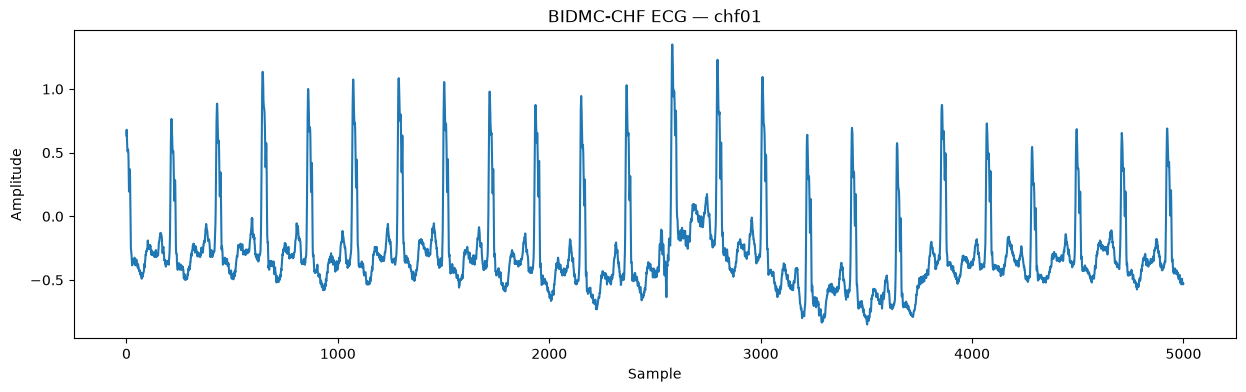

In [14]:
plt.figure(figsize=(15, 4))

plt.plot(record.p_signal[:5000, 0])

plt.title(f"BIDMC-CHF ECG — {record_name}")
plt.xlabel("Sample")
plt.ylabel("Amplitude")

plt.show()

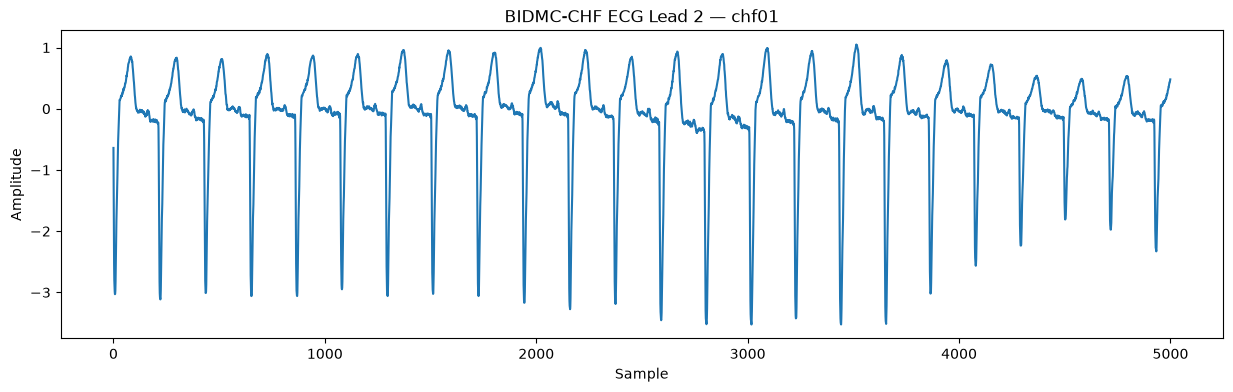

In [15]:
plt.figure(figsize=(15, 4))

plt.plot(record.p_signal[:5000, 1])

plt.title(f"BIDMC-CHF ECG Lead 2 — {record_name}")
plt.xlabel("Sample")
plt.ylabel("Amplitude")

plt.show()

In [16]:
import os

files = os.listdir("../data/raw/chfdb")

[f for f in files if record_name in f]

['chf01.dat', 'chf01.ecg', 'chf01.hea', 'chf01.hea-']

In [18]:
header_path = f"../data/raw/chfdb/{record_name}.hea"

print(open(header_path, "r").read())

chf01 2 250 17994491 10:00:00
chf01.dat 212 0 12 0 127 17579 0 ECG1
chf01.dat 212 0 12 0 -128 21162 0 ECG2
#Age: 71  Sex: M  NYHA class: III-IV



In [1]:
import os

chf2db_path = "../data/raw/chf2db"

files = sorted(os.listdir(chf2db_path))

print("Total files:", len(files))
print("\nFirst 20 files:")
for f in files[:20]:
    print(f)

Total files: 58

First 20 files:
chf201.ecg
chf201.hea
chf202.ecg
chf202.hea
chf203.ecg
chf203.hea
chf204.ecg
chf204.hea
chf205.ecg
chf205.hea
chf206.ecg
chf206.hea
chf207.ecg
chf207.hea
chf208.ecg
chf208.hea
chf209.ecg
chf209.hea
chf210.ecg
chf210.hea


In [2]:
print("\nFile extensions:")

extensions = {}

for f in files:
    ext = os.path.splitext(f)[1]
    extensions[ext] = extensions.get(ext, 0) + 1

print(extensions)


File extensions:
{'.ecg': 29, '.hea': 29}


In [4]:
import os
import wfdb

chf2db_path = "../data/raw/chf2db"

print("Path exists:", os.path.exists(chf2db_path))

Path exists: True


In [5]:
import wfdb

record_name = "chf201"

annotation = wfdb.rdann(
    f"{chf2db_path}/{record_name}",
    extension="ecg"
)

print(annotation)

In [6]:
print("Number of annotations:", len(annotation.sample))
print("First 20 sample positions:")
print(annotation.sample[:20])

Number of annotations: 112233
First 20 sample positions:
[ 751  848  949 1047 1141 1238 1336 1434 1527 1620 1715 1812 1908 2002
 2100 2202 2304 2401 2497 2595]


In [7]:
print("Annotation symbols:")
print(annotation.symbol[:20])

Annotation symbols:
['N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']


In [8]:
print("Sampling frequency:", annotation.fs)

Sampling frequency: 128


In [9]:
print("First 20 annotation samples:")
print(annotation.sample[:20])

First 20 annotation samples:
[ 751  848  949 1047 1141 1238 1336 1434 1527 1620 1715 1812 1908 2002
 2100 2202 2304 2401 2497 2595]


In [10]:
import numpy as np

rr_samples = np.diff(annotation.sample)

print("First 20 RR intervals in samples:")
print(rr_samples[:20])

First 20 RR intervals in samples:
[ 97 101  98  94  97  98  98  93  93  95  97  96  94  98 102 102  97  96
  98  99]


In [11]:
rr_ms = (rr_samples / annotation.fs) * 1000

print("First 20 RR intervals in milliseconds:")
print(rr_ms[:20])

First 20 RR intervals in milliseconds:
[757.8125 789.0625 765.625  734.375  757.8125 765.625  765.625  726.5625
 726.5625 742.1875 757.8125 750.     734.375  765.625  796.875  796.875
 757.8125 750.     765.625  773.4375]


In [12]:
print("Mean RR:", np.mean(rr_ms), "ms")
print("Median RR:", np.median(rr_ms), "ms")
print("Min RR:", np.min(rr_ms), "ms")
print("Max RR:", np.max(rr_ms), "ms")

Mean RR: 738.0360826234942 ms
Median RR: 734.375 ms
Min RR: 46.875 ms
Max RR: 5476.5625 ms


In [13]:
print("RR < 300 ms:", np.sum(rr_ms < 300))
print("RR > 2000 ms:", np.sum(rr_ms > 2000))
print("Total RR intervals:", len(rr_ms))

RR < 300 ms: 43
RR > 2000 ms: 3
Total RR intervals: 112232


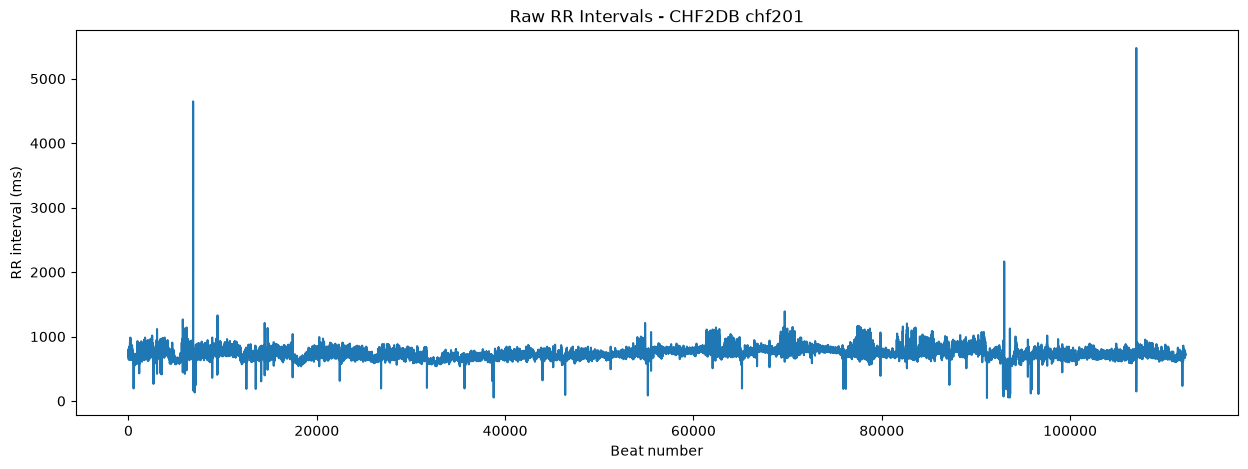

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

plt.plot(rr_ms)

plt.title("Raw RR Intervals - CHF2DB chf201")
plt.xlabel("Beat number")
plt.ylabel("RR interval (ms)")

plt.show()

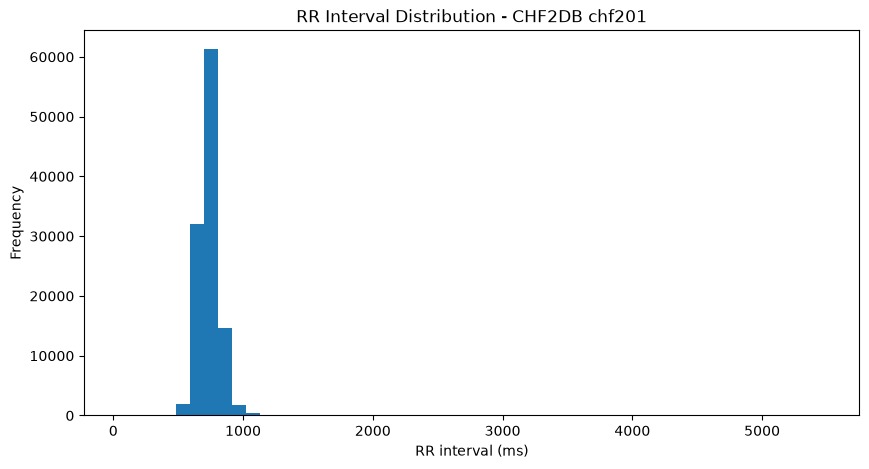

In [15]:
plt.figure(figsize=(10, 5))

plt.hist(rr_ms, bins=50)

plt.title("RR Interval Distribution - CHF2DB chf201")
plt.xlabel("RR interval (ms)")
plt.ylabel("Frequency")

plt.show()

In [16]:
chfdb_path = "../data/raw/chfdb"

files = sorted(os.listdir(chfdb_path))

print("Total files:", len(files))

for f in files:
    print(f)

Total files: 65
ANNOTATORS
RECORDS
SHA256SUMS.txt
chf01.dat
chf01.ecg
chf01.hea
chf01.hea-
chf02.dat
chf02.ecg
chf02.ecg-
chf02.hea
chf02.hea-
chf03.dat
chf03.ecg
chf03.hea
chf03.hea-
chf04.dat
chf04.ecg
chf04.ecg-
chf04.hea
chf04.hea-
chf05.dat
chf05.ecg
chf05.hea
chf05.hea-
chf06.dat
chf06.ecg
chf06.hea
chf06.hea-
chf07.dat
chf07.ecg
chf07.hea
chf07.hea-
chf08.dat
chf08.ecg
chf08.hea
chf08.hea-
chf09.dat
chf09.ecg
chf09.hea
chf09.hea-
chf10.dat
chf10.ecg
chf10.hea
chf10.hea-
chf11.dat
chf11.ecg
chf11.hea
chf11.hea-
chf12.dat
chf12.ecg
chf12.hea
chf12.hea-
chf13.dat
chf13.ecg
chf13.hea
chf13.hea-
chf14.dat
chf14.ecg
chf14.hea
chf14.hea-
chf15.dat
chf15.ecg
chf15.hea
chf15.hea-


In [17]:
ecg_files = [f for f in files if f.endswith(".ecg")]

print("ECG annotation files:")
print(ecg_files)

ECG annotation files:
['chf01.ecg', 'chf02.ecg', 'chf03.ecg', 'chf04.ecg', 'chf05.ecg', 'chf06.ecg', 'chf07.ecg', 'chf08.ecg', 'chf09.ecg', 'chf10.ecg', 'chf11.ecg', 'chf12.ecg', 'chf13.ecg', 'chf14.ecg', 'chf15.ecg']


In [18]:
annotation_chfdb = wfdb.rdann(
    f"{chfdb_path}/chf01",
    extension="ecg"
)

print(annotation_chfdb)

In [19]:
rr_samples_chfdb = np.diff(annotation_chfdb.sample)

rr_ms_chfdb = (
    rr_samples_chfdb / annotation_chfdb.fs
) * 1000

print("First 20 RR intervals:")
print(rr_ms_chfdb[:20])

print("\nMean:", np.mean(rr_ms_chfdb))
print("Median:", np.median(rr_ms_chfdb))
print("Min:", np.min(rr_ms_chfdb))
print("Max:", np.max(rr_ms_chfdb))

First 20 RR intervals:
[784. 856. 860. 860. 852. 860. 864. 856. 864. 868. 860. 864. 856. 852.
 848. 848. 856. 840. 860. 848.]

Mean: 952.7490965888785
Median: 948.0
Min: 396.0
Max: 2092.0


In [20]:
print(annotation)